# Esse é o tratamento que cada arquivo recebe


## Carregando as variáveis de ambiente
*Estou carregando pelo pandas e não pelo numpy. Por que? Porque eu quero!*

In [ ]:
import pandas as pd
import numpy as np
import filter as ft
import utils2 as ut2
import old_stuff.utils as ut
import matplotlib.pyplot as plt
from configuration_new import Configuration

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

cfg = Configuration()
path = "data/"

## Carregando o arquivo

In [2]:
arquivo="02010001_still.txt"
subject_id, subject_state = arquivo.split('.')[0].split('_')

data_raw = pd.read_csv(path+arquivo, sep=" ", header=None, names=cfg.electrode_labels)

data_raw = np.transpose(data_raw.to_numpy().astype(float)) #Convertendo os dados para np.ndarray

### Corrige o sinal dos valores
Os valores são lidos em microvolts e depois passam por um conversor A/D (Analógico-Digital) de **24 bits** (importante verificar esse valor conforme os dados utilizados) que vai converter para um valor inteiro entre 0 e 2^24. Portanto, valores que são maiores que 2^23 são números negativos e menores que isso são positivos.


In [3]:
data_np, changed_values_on_wraparound = ft.fix_integer_wraparound(data_raw)
print(changed_values_on_wraparound)

0


### Verificando se os dados estão de acordo com o esperado


In [ ]:
data_np = np.ascontiguousarray(data_np)
if ft.is_data_shape_ok(data_np)!= True:
    print('DEU MERDA')

print('ARQUIVO ESTÁ NO TAMANHO ESPERADO')


ARQUIVO ESTÁ NO TAMANHO ESPERADO
(3, 300740)


### Filtrando o sinal

In [5]:
data_np, filter_info = ft.apply_filter(data_np, cfg) 

# O comando acima substitui essa sequência de comandos
# data_np = ft.subtract_mean_value(data_np)

# data_np = ft.notch_filter(data_np) # Filtrando o ruído do circuito elétrico (default = 50Hz)

# data_np = ft.band_pass_filter(data_np) # Filtro passa faixa (default=[1,40])

# cut_size = int( round( cfg.sampling_frequency * cfg.exclusion_time_window ))

# data_np = ft.cut_array_edges(data_np, cut_size)

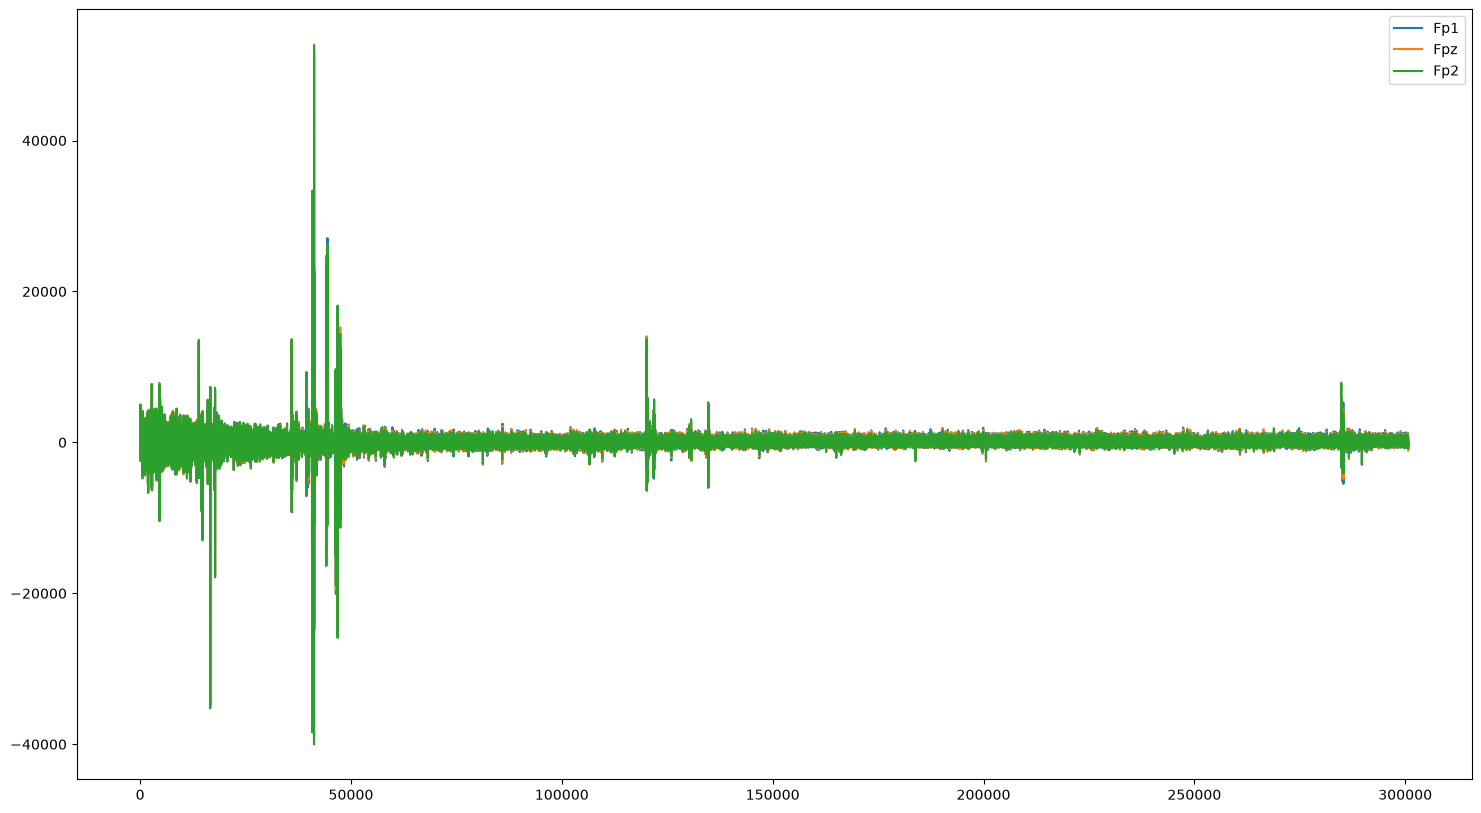

In [6]:
data = pd.DataFrame(np.transpose(data_np), columns=cfg.electrode_labels)
data.plot(figsize=(18,10));


## Calculando o perfil temporal de cada bloco

**Função: spectral_profile_blocked**
1) Os dados são segmentados em janelas com tempo igual ao "block_time".
2) Para cada seguimento é calculado:
   1) A densidade de espectral de potência usando o método de welch (usando a função welch_power_spectral_density);
   2) O perfil espectral é traçado (spectral_profile).

Perfil Espectral: Para cada faixa de frequência (ver em vars.py o PROFILE_BANDS) é feita a soma da densidade espectral sobre a soma da densidade espectral de uma faixa de referência.
No final são calculado os índices oculares, razão muscular e a contagem rms.

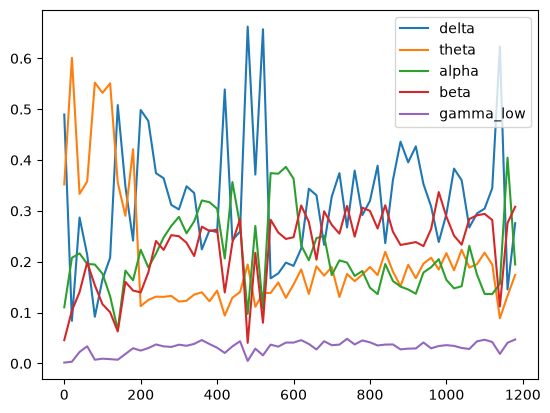

In [7]:
profile = ut2.spectral_profile_blocked(data_np, cfg.sampling_frequency, cfg.block_time)
plt.plot(profile['t_start_s'], profile['prof_delta'], label = 'delta')
plt.plot(profile['t_start_s'], profile['prof_theta'], label = 'theta')
plt.plot(profile['t_start_s'], profile['prof_alpha'], label = 'alpha')
plt.plot(profile['t_start_s'], profile['prof_beta'], label = 'beta')
plt.plot(profile['t_start_s'], profile['prof_gamma_low'], label = 'gamma_low')
plt.legend()
plt.show()
# print(profile)

### Quality Control (QC) Metrics

In [10]:
metrics = ut2.quality_control_metrics(data_raw, data_np, filtering_info=filter_info, subject_id=subject_id, file_name=arquivo, eeg_task=subject_state, n_wraparound=changed_values_on_wraparound)
for key in metrics:
    print(key+": "+str(metrics[key])) 

subject_id: 02010001
source_name: 02010001_still.txt
task: still
n_samples: 301740
duration_s: 1206.96
finite: True
flat_channels: 0
n_wraparound_fixed: 0
saturation_fraction: 0.0
zero_diff_fraction: 2.9827102230735834e-05
line_noise_ratio_raw: 128.2970315721516
line_noise_ratio_post: 0.00028814627975785184
notch_applied: True
ocular_index: 0.2554269426004917
muscle_ratio: 0.06320870588388504
nonstationarity_cv: 3.3626856362418085
min_channel_corr: 0.9737122765422982
rms_counts: 900.6954194295328
log_rms_counts: 2.9545779541043253
